# **⚙️ Set up**

## 📖 Contexto do Dataset

Antes de qualquer código, responder:

* Qual é o objetivo da análise
* Qual pergunta queremos responder
* Qual a unidade de observação
* O que cada linha representa
* O que cada coluna representa
* Se houver mais de uma tabela, como elas se relacionam

## 📦 Importação de Bibliotecas

In [1]:
# importar manipular o sistema
from google.colab import files
import os

In [2]:
# importar bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

In [3]:
# importar plotly para gráficos interativos
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# **📥 Extract**

Dado de exemplo: https://drive.google.com/uc?export=download&id=18vaTBJztI-YHE4ZFGoQyMjkWtFGWRYkRXseht4ZvuTw

## 📁 Upload do Dataset

### 📄 Usando Excel:

In [645]:
uploaded = files.upload()

Saving Dados - TCC - Planilhas - Modificação 1 (2).xlsx to Dados - TCC - Planilhas - Modificação 1 (2) (3).xlsx


In [646]:
def carregar_dataset(uploaded, sheet_name=None):

    # pegar o nome do arquivo enviado no upload
    arquivo = list(uploaded.keys())[0]

    print("Arquivo identificado:", arquivo)

    try:
      # tentar ler como Excel moderno
      df = pd.read_excel(arquivo, sheet_name=sheet_name, engine="openpyxl")
      print("Arquivo lido como Excel (xlsx)")

    except:
      try:
        # tentar Excel antigo
        df = pd.read_excel(arquivo, sheet_name=sheet_name, engine="xlrd")
        print("Arquivo lido como Excel antigo (xls)")

      except:
        raise ValueError("Não foi possível identificar o formato do arquivo")

    print("Excel carregado com sucesso")

    return df

In [408]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI O NOME DA ABA DA PLANILHA QUE DESEJA CARREGAR
</div>
"""))

In [647]:
# Basta modificar o nome da aba entre aspas
sheet_name_1 = "Faturamento"

In [648]:
df = carregar_dataset(uploaded, sheet_name=sheet_name_1)

Arquivo identificado: Dados - TCC - Planilhas - Modificação 1 (2) (3).xlsx
Arquivo lido como Excel (xlsx)
Excel carregado com sucesso


### 📄 Usando CSV:

In [ ]:
uploaded = files.upload()

In [ ]:
def carregar_csv(uploaded, sep=",", encoding="utf-8"):

    # pegar o nome do arquivo enviado
    arquivo = list(uploaded.keys())[0]

    print("Arquivo identificado:", arquivo)

    # ler o CSV
    df = pd.read_csv(
        arquivo,
        sep=sep,        # separador (vírgula, ponto e vírgula etc.)
        encoding=encoding
    )
    print("Arquivo lido como CSV")

    print("CSV carregado com sucesso")

    return df

In [ ]:
df = carregar_csv(uploaded)

## 🔎 Avaliação Sumária do Dataset

In [649]:
# mostrar dimensão do dataset
print("Número de linhas:", df.shape[0])
print("Número de colunas:", df.shape[1])

Número de linhas: 1239
Número de colunas: 15


In [650]:
# calcular percentual de valores faltantes
missing_percent = df.isnull().mean() * 100
print("Percentual de valores faltantes por variável:")
print(missing_percent.sort_values(ascending=False))

Percentual de valores faltantes por variável:
Cliente Origem                45.924132
Cliente Cidade                11.864407
Cliente Sexo                   9.120258
Cliente Data Nascimento        8.313156
Data Lançamento                0.000000
Id Atendimento                 0.000000
Receita Código                 0.000000
Cliente Nome                   0.000000
Cliente ID                     0.000000
Valor de venda                 0.000000
Quantidade Vendida             0.000000
Profissional Nome              0.000000
Profissional Especialidade     0.000000
Data de Pagamento              0.000000
Forma Pagamento                0.000000
dtype: float64


In [651]:
# calcular número de valores únicos
valores_unicos = df.nunique()
print("Número de valores únicos por variável:")
print(valores_unicos.sort_values(ascending=False))

Número de valores únicos por variável:
Id Atendimento                1033
Cliente ID                     679
Cliente Nome                   679
Cliente Data Nascimento        596
Data de Pagamento              499
Data Lançamento                366
Valor de venda                 200
Receita Código                 127
Profissional Nome               16
Cliente Cidade                   9
Profissional Especialidade       8
Quantidade Vendida               6
Forma Pagamento                  6
Cliente Origem                   4
Cliente Sexo                     4
dtype: int64


## ✅ Dicionário e Diagrama de Relacionamento de Entidades

| 📌 Nome da Coluna            | 🏷️ Tipo de Dado      | 📝 Descrição |
|-----------------------------|-------------------|----------------------------------------------|
| **Data_Lancamento**         | Data              | Data em que a receita foi registrada no sistema. |
| **ID_Atendimento**          | Inteiro           | Identificação única do atendimento do paciente. |
| **Receita_Codigo**          | Inteiro           | Código do tipo de receita gerada ou serviço faturado. |
| **Quantidade_Vendida**      | Inteiro           | Número de unidades do procedimento vendido. |
| **Valor_Venda**            | Decimal           | Valor total da venda em reais (BRL). |
| **Cliente_ID**              | Inteiro           | Identificação única do cliente (paciente). |
| **Cliente_Nome**            | Texto             | Nome do cliente que realizou o procedimento. |
| **Cliente_Sexo**            | Texto             | Sexo do cliente (M = Masculino, F = Feminino). |
| **Cliente_DataNascimento**  | Data              | Data de nascimento do paciente. |
| **Cliente_Origem**          | Texto             | Fonte de aquisição do cliente (Indicação, Google, Redes Sociais, Convênio, etc.). |
| **Cliente_Cidade**          | Texto             | Cidade onde o cliente reside. |
| **Profissional_Nome**       | Texto             | Nome do profissional responsável pelo atendimento. |
| **Profissional_Especialidade** | Texto          | Especialidade do profissional (ex.: Cirurgia Plástica, Dermatologia). |
| **Data_Pagamento**          | Data              | Data em que o pagamento foi realizado. |
| **Forma_Pagamento**         | Texto             | Forma de pagamento utilizada (Pix, TED/DOC, Cartão de Crédito, Cartão de Débito, Boleto, etc.). |

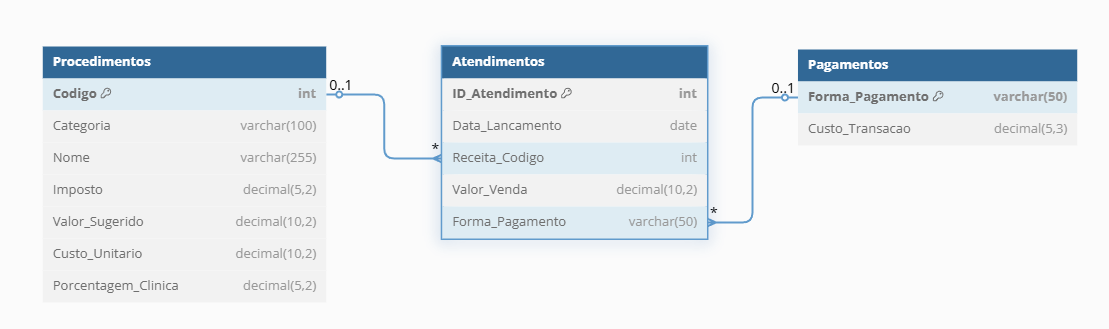

* Atendimentos → Procedimentos (N:1) → Um atendimento pode ter apenas um procedimento, mas um mesmo procedimento pode ser usado em vários atendimentos.

* Atendimentos → Pagamentos (N:1) → Cada atendimento tem uma forma de pagamento associada, mas a tabela de Pagamentos contém apenas os tipos de pagamento disponíveis.

# **🔄 Transform**

## 📝 Nomenclaturização das variáveis

Antes de iniciar a análise, é importante revisar e padronizar os nomes das colunas do dataset.  
Nomes claros e consistentes facilitam a leitura do código, evitam erros e tornam a análise mais organizada.

Boas práticas para nomear variáveis:

- Usar letras minúsculas
- Separar palavras com underscore (_)
- Evitar espaços, acentos e caracteres especiais
- Utilizar nomes descritivos, que indiquem o significado da variável
- Manter um padrão consistente em todo o dataset

**Exemplos:**

| Antes | Depois |
|------|------|
| Idade Paciente | idade_paciente |
| SexoPaciente | sexo_paciente |
| Pressão Arterial | pressao_arterial |
| Vl Total | valor_total |

Padronizar os nomes das variáveis melhora a qualidade do código e facilita a comunicação das análises.

In [652]:
for columns in df.columns:
  print(columns)

Data Lançamento
Id Atendimento
Receita Código
Quantidade Vendida
Valor de venda
Cliente ID
Cliente Nome
Cliente Sexo
Cliente Data Nascimento
Cliente Origem
Cliente Cidade
Profissional Nome
Profissional Especialidade
Data de Pagamento
Forma Pagamento


In [653]:
def renomear_colunas(df, mapa_colunas):

    # Mostrar os nomes das colunas antes da padronização
    # .columns retorna todas as colunas do dataframe
    # .tolist() transforma em lista para facilitar leitura
    print("\nColunas antes da padronização:")
    print(df.columns.tolist())

    # Renomear colunas usando o dicionário informado
    # O dicionário deve ter o formato:
    # {"nome_original": "nome_padronizado"}
    df = df.rename(columns=mapa_colunas)

    # Mostrar os nomes das colunas após a padronização
    # Isso permite verificar rapidamente se a transformação funcionou
    print("\nColunas após padronização:")
    print(df.columns.tolist())

    # Retornar o dataframe atualizado
    return df

In [654]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI O NOME DE CADA COLUNA, COLOCANDO O PAR DO NOME ORIGINAL COM O NOME DESEJADO
</div>
"""))

In [655]:
# Basta modificar aqui o dicionário

mapa_colunas = {
    "Data Lançamento": "lancamento_data",
    "Id Atendimento": "atendimento_id",
    "Receita Código": "receita_codigo",
    "Quantidade Vendida": "receita_quantidade_vendida",
    "Valor de venda": "receita_valor_venda",
    "Cliente ID": "cliente_id",
    "Cliente Nome": "cliente_nome",
    "Cliente Sexo": "cliente_sexo",
    "Cliente Data Nascimento": "cliente_data_nascimento",
    "Cliente Origem": "cliente_origem",
    "Cliente Cidade": "cliente_cidade",
    "Profissional Nome": "profissional_nome",
    "Profissional Especialidade": "profissional_especialidade",
    "Data de Pagamento": "pagamento_data",
    "Forma Pagamento": "pagamento_forma"
}

In [656]:
df = renomear_colunas(df, mapa_colunas)


Colunas antes da padronização:
['Data Lançamento', 'Id Atendimento', 'Receita Código', 'Quantidade Vendida', 'Valor de venda', 'Cliente ID', 'Cliente Nome', 'Cliente Sexo', 'Cliente Data Nascimento', 'Cliente Origem', 'Cliente Cidade', 'Profissional Nome', 'Profissional Especialidade', 'Data de Pagamento', 'Forma Pagamento']

Colunas após padronização:
['lancamento_data', 'atendimento_id', 'receita_codigo', 'receita_quantidade_vendida', 'receita_valor_venda', 'cliente_id', 'cliente_nome', 'cliente_sexo', 'cliente_data_nascimento', 'cliente_origem', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'pagamento_data', 'pagamento_forma']


## 📌 Tipagem das Variáveis

### 🧪 Diagnóstico

In [657]:
# mostrar tipos das variáveis
print("Tipos atuais das variáveis:\n")
print(df.dtypes)

Tipos atuais das variáveis:

lancamento_data               datetime64[ns]
atendimento_id                         int64
receita_codigo                         int64
receita_quantidade_vendida             int64
receita_valor_venda                  float64
cliente_id                             int64
cliente_nome                          object
cliente_sexo                          object
cliente_data_nascimento       datetime64[ns]
cliente_origem                        object
cliente_cidade                        object
profissional_nome                     object
profissional_especialidade            object
pagamento_data                datetime64[ns]
pagamento_forma                       object
dtype: object


In [658]:
# variáveis numéricas
colunas_numericas = df.select_dtypes(include=np.number).columns

# variáveis categóricas (texto)
colunas_categoricas = df.select_dtypes(include="object").columns

# variáveis de data
colunas_datas = df.select_dtypes(include="datetime").columns

print("Quantidade de variáveis numéricas:", len(colunas_numericas))
print("Quantidade de variáveis categóricas:", len(colunas_categoricas))
print("Quantidade de variáveis de data:", len(colunas_datas))

Quantidade de variáveis numéricas: 5
Quantidade de variáveis categóricas: 7
Quantidade de variáveis de data: 3


In [659]:
# Mostrar quais são de qual tipo originalmente

print("\nVariáveis numéricas:")
print(list(colunas_numericas))

print("\nVariáveis categóricas:")
print(list(colunas_categoricas))

print("\nVariáveis de data:")
print(list(colunas_datas))


Variáveis numéricas:
['atendimento_id', 'receita_codigo', 'receita_quantidade_vendida', 'receita_valor_venda', 'cliente_id']

Variáveis categóricas:
['cliente_nome', 'cliente_sexo', 'cliente_origem', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'pagamento_forma']

Variáveis de data:
['lancamento_data', 'cliente_data_nascimento', 'pagamento_data']


###  🔧 Tratamento

In [660]:
def ajustar_tipos_variaveis(
    df,
    colunas_string=None,
    colunas_category=None,
    colunas_numeric=None,
    colunas_datetime=None,
    errors_numeric="coerce",
    errors_datetime="coerce"
):

    # mostrar os tipos antes dos ajustes
    print("\nTipos antes dos ajustes:\n")
    print(df.dtypes)

    # evitar problema caso o usuário não informe alguma lista
    if colunas_string is None:
        colunas_string = []

    if colunas_category is None:
        colunas_category = []

    if colunas_numeric is None:
        colunas_numeric = []

    if colunas_datetime is None:
        colunas_datetime = {}

    # ---------------------------------------------------------
    # converter colunas para texto
    # útil para IDs e códigos que não devem ser tratados como número
    # ---------------------------------------------------------
    for col in colunas_string:
        if col in df.columns:
            df[col] = df[col].astype("string")
            print(f"{col} convertida para string")

    # ---------------------------------------------------------
    # converter colunas para categóricas
    # útil para variáveis com classes como sexo, estado, tipo etc.
    # ---------------------------------------------------------
    for col in colunas_category:
        if col in df.columns:
            df[col] = df[col].astype("category")
            print(f"{col} convertida para category")

    # ---------------------------------------------------------
    # converter colunas para numéricas
    # errors='coerce' transforma valores inválidos em NaN
    # ---------------------------------------------------------
    for col in colunas_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors=errors_numeric)
            print(f"{col} convertida para numeric")

    # ---------------------------------------------------------
    # converter colunas para data
    # colunas_datetime deve ser um dicionário no formato:
    # {"nome_coluna": "formato"}
    #
    # exemplo:
    # {"data_pagamento": "%d/%m/%Y"}
    #
    # se formato = None, pandas tenta inferir automaticamente
    # ---------------------------------------------------------
    for col, formato in colunas_datetime.items():
        if col in df.columns:
            df[col] = pd.to_datetime(
                df[col],
                format=formato,
                errors=errors_datetime
            )
            print(f"{col} convertida para datetime com formato {formato}")

    # mostrar os tipos após os ajustes
    print("\nTipos após ajustes:\n")
    print(df.dtypes)

    # retornar dataframe atualizado
    return df

In [661]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ DEFINA AQUI AS COLUNAS QUE DESEJA ALTERAR O TIPO
</div>
"""))

In [662]:
colunas_string = ["atendimento_id", "receita_codigo", "cliente_id"]

colunas_category = ["cliente_sexo", "pagamento_forma"]

colunas_numeric = ["receita_valor_venda", "receita_quantidade_vendida"]

colunas_datetime = {
    "cliente_data_nascimento": "%d/%m/%Y",
    "pagamento_data": "%d/%m/%Y"
}

In [663]:
df = ajustar_tipos_variaveis(
    df,
    colunas_string=colunas_string,
    colunas_category=colunas_category,
    colunas_numeric=colunas_numeric,
    colunas_datetime=colunas_datetime
)


Tipos antes dos ajustes:

lancamento_data               datetime64[ns]
atendimento_id                         int64
receita_codigo                         int64
receita_quantidade_vendida             int64
receita_valor_venda                  float64
cliente_id                             int64
cliente_nome                          object
cliente_sexo                          object
cliente_data_nascimento       datetime64[ns]
cliente_origem                        object
cliente_cidade                        object
profissional_nome                     object
profissional_especialidade            object
pagamento_data                datetime64[ns]
pagamento_forma                       object
dtype: object
atendimento_id convertida para string
receita_codigo convertida para string
cliente_id convertida para string
cliente_sexo convertida para category
pagamento_forma convertida para category
receita_valor_venda convertida para numeric
receita_quantidade_vendida convertida para numeric


## 🔎 Avaliação Sumária das Variáveis

### 🔢 Avaliação Sumária dos Atributos Numéricos

In [664]:
# selecionar apenas variáveis numéricas
numericas = df.select_dtypes(include=np.number)

# mostrar os nomes das variáveis numéricas
print("Variáveis categóricas numéricas:")
print(list(numericas.columns))

Variáveis categóricas numéricas:
['receita_quantidade_vendida', 'receita_valor_venda']


In [665]:
def resumo_variaveis_numericas(df, casas_decimais=2):

    # selecionar variáveis numéricas
    numericas = df.select_dtypes(include=np.number)

    # estatísticas básicas
    resumo = numericas.describe().T

    # valores faltantes
    resumo["missing"] = numericas.isna().sum()
    resumo["missing_%"] = numericas.isna().mean() * 100

    # calcular quartis
    Q1 = numericas.quantile(0.25)
    Q3 = numericas.quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # limites de outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    resumo["lim_inf_outlier_estatatisco"] = limite_inferior
    resumo["lim_sup_outlier_estatatisco"] = limite_superior

    # detectar outliers
    outliers = ((numericas < limite_inferior) | (numericas > limite_superior)).sum()

    resumo["outliers_estatistico"] = outliers
    resumo["outliers_estatistico_%"] = (outliers / len(df)) * 100

    # arredondar
    resumo = resumo.round(casas_decimais)

    return resumo

In [666]:
resumo_numericas = resumo_variaveis_numericas(df)
resumo_numericas

,count,mean,std,min,25%,50%,75%,max,missing,missing_%,lim_inf_outlier_estatatisco,lim_sup_outlier_estatatisco,outliers_estatistico,outliers_estatistico_%
receita_quantidade_vendida,1239.0,1.06,0.33,1.0,1.0,1.0,1.0,6.0,0,0.0,1.0,1.0,50,4.04
receita_valor_venda,1239.0,1107.54,1934.24,0.0,300.0,410.0,1100.0,20217.4,0,0.0,-900.0,2300.0,144,11.62


### 🏷️ Avaliação Sumária dos Atributos Categóricos

In [667]:
# selecionar variáveis do tipo texto, categoria ou booleanas
categoricas = df.select_dtypes(include=["object", "category", "bool"])

# mostrar os nomes das variáveis categóricas
print("Variáveis categóricas identificadas:")
print(list(categoricas.columns))

Variáveis categóricas identificadas:
['cliente_nome', 'cliente_sexo', 'cliente_origem', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'pagamento_forma']


In [668]:
def resumo_variaveis_categoricas(df, top_n=10):

    import pandas as pd

    # selecionar variáveis categóricas
    categoricas = df.select_dtypes(include=["object", "category", "bool"])

    # para cada coluna categórica
    for col in categoricas.columns:

        print("\n" + "="*60)
        print(f"Variável categórica: {col}")
        print("="*60)

        # frequência absoluta
        freq = df[col].value_counts(dropna=False)

        # frequência relativa
        pct = df[col].value_counts(dropna=False, normalize=True) * 100

        # montar tabela
        tabela = pd.DataFrame({
            "frequencia": freq,
            "percentual_%": pct
        })

        # percentual acumulado
        tabela["percentual_acumulado_%"] = tabela["percentual_%"].cumsum()

        # renomear NaN
        tabela.index = tabela.index.fillna("Nulo")

        # arredondar
        tabela = tabela.round(2)

        # mostrar top categorias
        print(f"\nTop {top_n} categorias mais frequentes:")
        display(tabela.head(top_n))

        print("\nResumo rápido:")
        print(f"Total de categorias: {df[col].nunique()}")
        print(f"Valores faltantes: {df[col].isna().sum()}")

        cobertura = tabela["percentual_%"].head(top_n).sum().round(2)
        print(f"Cobertura das top {top_n} categorias: {cobertura}%")

In [669]:
resumo_variaveis_categoricas(df)


Variável categórica: cliente_nome

Top 10 categorias mais frequentes:


,frequencia,percentual_%,percentual_acumulado_%
cliente_nome,,,
Denise Marques Casa Nova,27,2.18,2.18
Ana Maria Mendes Castilho,17,1.37,3.55
Adriane Costa Zolio,11,0.89,4.44
Juliana Ferreira Carvalho,11,0.89,5.33
Luciana de Oliveira Bianchini,11,0.89,6.21
Vanessa Lima Gonçalves,11,0.89,7.10
Patrícia Almeida Costa,9,0.73,7.83
Renata Duarte Farias,9,0.73,8.56
Renata Rocha de Castro,9,0.73,9.28



Resumo rápido:
Total de categorias: 679
Valores faltantes: 0
Cobertura das top 10 categorias: 10.03%

Variável categórica: cliente_sexo

Top 10 categorias mais frequentes:


,frequencia,percentual_%,percentual_acumulado_%
cliente_sexo,,,
F,609,49.15,49.15
Feminino,408,32.93,82.08
Nulo,113,9.12,91.20
M,95,7.67,98.87
Masculino,14,1.13,100.00



Resumo rápido:
Total de categorias: 4
Valores faltantes: 113
Cobertura das top 10 categorias: 100.0%

Variável categórica: cliente_origem

Top 10 categorias mais frequentes:


...


Resumo rápido:
Total de categorias: 16
Valores faltantes: 0
Cobertura das top 10 categorias: 98.3%

Variável categórica: profissional_especialidade

Top 10 categorias mais frequentes:


,frequencia,percentual_%,percentual_acumulado_%
profissional_especialidade,,,
Cirurgia Plástica,621,50.12,50.12
Ginecologia,266,21.47,71.59
Dermatologia,222,17.92,89.51
Nutrologia,106,8.56,98.06
Psicólogo,13,1.05,99.11
Nutricionista,9,0.73,99.84
Fisioterapeuta,1,0.08,99.92
Educador Físico,1,0.08,100.00



Resumo rápido:
Total de categorias: 8
Valores faltantes: 0
Cobertura das top 10 categorias: 100.01%

Variável categórica: pagamento_forma

Top 10 categorias mais frequentes:


,frequencia,percentual_%,percentual_acumulado_%
pagamento_forma,,,
Pix,878,70.86,70.86
Cartão de crédito à vista,210,16.95,87.81
Cartão de débito,99,7.99,95.80
Dinheiro,48,3.87,99.68
TED/DOC,3,0.24,99.92
Boleto,1,0.08,100.00



Resumo rápido:
Total de categorias: 6
Valores faltantes: 0
Cobertura das top 10 categorias: 99.99%


### 📅 Avaliação Sumária dos Atributos de Data

In [670]:
# selecionar apenas variáveis numéricas
numericas = df.select_dtypes(include=["datetime"])

# mostrar os nomes das variáveis numéricas
print("Variáveis de data:")
print(list(numericas.columns))

Variáveis de data:
['lancamento_data', 'cliente_data_nascimento', 'pagamento_data']


In [671]:
def resumo_variaveis_data(df):

    import pandas as pd

    # selecionar colunas de data
    datas = df.select_dtypes(include=["datetime"])

    # para cada coluna de data
    for col in datas.columns:

        print("\n" + "="*60)
        print(f"Variável de data: {col}")
        print("="*60)

        serie = df[col]

        data_min = serie.min()
        data_max = serie.max()

        intervalo = data_max - data_min

        print(f"Total de registros: {len(serie)}")
        print(f"Valores faltantes: {serie.isna().sum()}")
        print(f"Data mínima: {data_min}")
        print(f"Data máxima: {data_max}")
        print(f"Intervalo temporal: {intervalo}")

        print("\nDistribuição por ano:")
        display(serie.dt.year.value_counts().sort_index())

        print("\nDistribuição por mês:")
        display(serie.dt.month.value_counts().sort_index())

In [672]:
resumo_variaveis_data(df)


Variável de data: lancamento_data
Total de registros: 1239
Valores faltantes: 0
Data mínima: 2021-10-18 00:00:00
Data máxima: 2024-05-31 00:00:00
Intervalo temporal: 956 days 00:00:00

Distribuição por ano:


,count
lancamento_data,
2021,6
2022,225
2023,439
2024,569



Distribuição por mês:


,count
lancamento_data,
1,95
2,120
3,234
4,182
5,190
6,51
7,61
8,66
9,52



Variável de data: cliente_data_nascimento
Total de registros: 1239
Valores faltantes: 103
Data mínima: 1936-05-14 00:00:00
Data máxima: 2014-02-06 00:00:00
Intervalo temporal: 28392 days 00:00:00

Distribuição por ano:


...

,count
cliente_data_nascimento,
1.0,107
2.0,105
3.0,81
4.0,95
5.0,119
6.0,146
7.0,64
8.0,101
9.0,60



Variável de data: pagamento_data
Total de registros: 1239
Valores faltantes: 0
Data mínima: 2021-10-21 00:00:00
Data máxima: 2024-07-05 00:00:00
Intervalo temporal: 988 days 00:00:00

Distribuição por ano:


,count
pagamento_data,
2021,5
2022,224
2023,433
2024,577



Distribuição por mês:


,count
pagamento_data,
1,86
2,94
3,169
4,205
5,199
6,116
7,68
8,57
9,54


## 🧹 Tratamento

### 🧱 Ao nível de colunas

#####🔀 Alteração da ordem das colunas


In [673]:
def reordenar_colunas(df, ordem_desejada):

    # Mostrar a ordem atual das colunas do dataframe
    print("\nOrdem atual das colunas:")
    print(df.columns.tolist())

    # Manter apenas colunas que realmente existem no dataframe
    # Isso evita erro caso o usuário informe alguma coluna
    # que não esteja presente na base de dados
    ordem_existente = [c for c in ordem_desejada if c in df.columns]

    # Identificar colunas que não foram especificadas pelo usuário
    # Essas colunas serão mantidas no final da tabela
    restantes = [c for c in df.columns if c not in ordem_existente]

    # Construir nova ordem das colunas
    # Primeiro as colunas desejadas
    # Depois as demais colunas restantes
    nova_ordem = ordem_existente + restantes

    # Aplicar nova ordem ao dataframe
    df = df[nova_ordem]

    # Mostrar a nova ordem das colunas após reorganização
    print("\nNova ordem das colunas:")
    print(df.columns.tolist())

    # Retornar dataframe atualizado
    return df

In [674]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI A ORDEM DAS COLUNAS DESEJADA
</div>
"""))

In [675]:
ordem = [
    "atendimento_id", # Primeira coluna
    "lancamento_data", # Segunda coluna
    "cliente_id", # Terceira coluna
    "cliente_nome",
    "cliente_sexo",
    "cliente_data_nascimento",
    "cliente_origem",
    "cliente_cidade",
    "profissional_nome",
    "profissional_especialidade",
    "receita_quantidade_vendida",
    "receita_valor_venda",
    "receita_codigo", # Antepenúltima coluna
    "pagamento_data", # Penúltima coluna
    "pagamento_forma" # Última coluna
]

In [676]:
df = reordenar_colunas(df, ordem)


Ordem atual das colunas:
['lancamento_data', 'atendimento_id', 'receita_codigo', 'receita_quantidade_vendida', 'receita_valor_venda', 'cliente_id', 'cliente_nome', 'cliente_sexo', 'cliente_data_nascimento', 'cliente_origem', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'pagamento_data', 'pagamento_forma']

Nova ordem das colunas:
['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome', 'cliente_sexo', 'cliente_data_nascimento', 'cliente_origem', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'receita_quantidade_vendida', 'receita_valor_venda', 'receita_codigo', 'pagamento_data', 'pagamento_forma']


##### ✂️ Descarte de  coluna desnecessária

In [677]:
def remover_colunas(df, colunas):

    # Mostrar a lista de colunas do dataframe antes da remoção
    # .columns retorna o índice das colunas
    # .tolist() transforma em lista para facilitar a leitura
    print("\nColunas antes:")
    print(df.columns.tolist())

    # Contar quantas colunas existem antes da remoção
    numero_colunas_antes = len(df.columns)
    print(f"\nNúmero de colunas antes: {numero_colunas_antes}")

    # Garantir que apenas colunas existentes sejam removidas
    # Isso evita erro caso o usuário digite uma coluna que não existe
    colunas_validas = [c for c in colunas if c in df.columns]

    # Remover as colunas válidas do dataframe
    # drop(columns=...) remove colunas específicas
    df = df.drop(columns=colunas_validas)

    # Informar quais colunas foram removidas
    print(f"\nColunas removidas: {colunas_validas}")

    # Mostrar as colunas restantes após a remoção
    print("\nColunas depois:")
    print(df.columns.tolist())

    # Contar quantas colunas restaram
    numero_colunas_depois = len(df.columns)
    print(f"\nNúmero de colunas depois: {numero_colunas_depois}")

    # Retornar o dataframe atualizado
    return df

In [678]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI O NOME DA COLUNA QUE DESEJA DESCARTAR
</div>
"""))

In [679]:
df = remover_colunas(df, ["cliente_origem"])


Colunas antes:
['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome', 'cliente_sexo', 'cliente_data_nascimento', 'cliente_origem', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'receita_quantidade_vendida', 'receita_valor_venda', 'receita_codigo', 'pagamento_data', 'pagamento_forma']

Número de colunas antes: 15

Colunas removidas: ['cliente_origem']

Colunas depois:
['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome', 'cliente_sexo', 'cliente_data_nascimento', 'cliente_cidade', 'profissional_nome', 'profissional_especialidade', 'receita_quantidade_vendida', 'receita_valor_venda', 'receita_codigo', 'pagamento_data', 'pagamento_forma']

Número de colunas depois: 14


##### 🗑️ Descarte de coluna com nulidade

In [680]:
def remover_colunas_muito_nulas(df, limite=0.9):

    # Mostrar o percentual de valores nulos em cada coluna
    # df.isna() identifica valores nulos
    # .mean() calcula a proporção de nulos por coluna
    # (pois True=1 e False=0)
    print("\nPercentual de valores nulos por coluna:")

    pct_nulos = df.isna().mean()

    # Multiplicamos por 100 para mostrar em porcentagem
    # round(2) limita a duas casas decimais
    # sort_values ordena da coluna com mais nulos para menos
    display((pct_nulos * 100).round(2).sort_values(ascending=False))

    # Identificar quais colunas ultrapassam o limite permitido
    # Exemplo: limite = 0.9 significa 90% de valores nulos
    colunas_remover = pct_nulos[pct_nulos > limite].index.tolist()

    # Mostrar quais colunas serão removidas
    print(f"\nColunas com mais de {limite*100:.0f}% de nulos:")
    print(colunas_remover)

    # Mostrar quantas colunas existem antes da remoção
    print(f"\nNúmero de colunas antes: {len(df.columns)}")

    # Remover as colunas identificadas
    # drop(columns=...) remove colunas específicas do dataframe
    df = df.drop(columns=colunas_remover)

    # Mostrar quantas colunas restaram após a remoção
    print(f"\nNúmero de colunas depois: {len(df.columns)}")

    # Mostrar a lista final de colunas
    print("\nColunas restantes:")
    print(df.columns.tolist())

    # Retornar o dataframe atualizado
    return df

In [681]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI O LIMITE DE NULO NA COLUNA QUE VOCÊ ACEITA
</div>
"""))

In [682]:
df = remover_colunas_muito_nulas(df, limite=0.10)


Percentual de valores nulos por coluna:


,0
cliente_cidade,11.86
cliente_sexo,9.12
cliente_data_nascimento,8.31
lancamento_data,0.00
cliente_nome,0.00
atendimento_id,0.00
cliente_id,0.00
profissional_nome,0.00
profissional_especialidade,0.00
receita_quantidade_vendida,0.00



Colunas com mais de 10% de nulos:
['cliente_cidade']

Número de colunas antes: 14

Número de colunas depois: 13

Colunas restantes:
['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome', 'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome', 'profissional_especialidade', 'receita_quantidade_vendida', 'receita_valor_venda', 'receita_codigo', 'pagamento_data', 'pagamento_forma']


### 📏 Ao nível de linhas

#####🔁 Substituição de linhas

In [683]:
def substituir_valores(df, coluna, mapa_substituicao):

    # Informar qual coluna será modificada
    print(f"\nSubstituindo valores na coluna: {coluna}")

    # Garantir que a coluna esteja no tipo "object"
    # Isso evita problemas quando a coluna está como
    # tipo categórico (category) e queremos alterar valores
    df[coluna] = df[coluna].astype("object")

    # Mostrar os valores únicos da coluna antes da substituição
    # unique() retorna os valores distintos presentes na coluna
    valores_antes = df[coluna].unique()
    print("\nValores antes:")
    print(valores_antes)

    # Aplicar substituição utilizando o dicionário informado
    # mapa_substituicao deve ter o formato:
    # {"valor_antigo": "valor_novo"}
    df[coluna] = df[coluna].replace(mapa_substituicao)

    # Mostrar os valores únicos após a substituição
    # Isso permite verificar se a transformação ocorreu corretamente
    valores_depois = df[coluna].unique()
    print("\nValores depois:")
    print(valores_depois)

    # Retornar dataframe atualizado
    return df

In [684]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI O MAPA DE SUBSTITUIÇÃO QUE VOCÊ DESEJA FAZER PARA UMA COLUNA ESPECÍFICA
</div>
"""))

In [685]:
mapa_colunas = {
    "M": "Masculino",
    "F": "Feminino"
}

In [686]:
df = substituir_valores(df, "cliente_sexo", mapa_colunas)


Substituindo valores na coluna: cliente_sexo

Valores antes:
['F' 'M' nan 'Feminino' 'Masculino']

Valores depois:
['Feminino' 'Masculino' nan]


#####🔢  Deleção em linhas nulas

In [687]:
def remover_linhas_nulas(df, colunas=None):

    # informar que o processo de remoção de linhas com nulos começou
    print("\nRemovendo linhas com valores nulos")

    # guardar número de linhas antes da remoção
    linhas_antes = len(df)
    print(f"Linhas antes: {linhas_antes}")

    # se nenhuma coluna for especificada,
    # remove qualquer linha que tenha pelo menos um valor nulo
    if colunas is None:
        df = df.dropna()

    # se forem especificadas colunas,
    # remove apenas linhas com nulos nessas colunas específicas
    else:
        df = df.dropna(subset=colunas)

    # guardar número de linhas após remoção
    linhas_depois = len(df)

    # mostrar resultado da limpeza
    print(f"Linhas depois: {linhas_depois}")

    # calcular quantas linhas foram removidas
    print(f"Linhas removidas: {linhas_antes - linhas_depois}")

    # retornar dataframe atualizado
    return df

In [734]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI AS COLUNAS EM QUE QUER AVALIAR NULOS PARA DELETAR LINHAS
</div>
"""))

In [688]:
df = remover_linhas_nulas(df, ["cliente_id", "pagamento_data"])


Removendo linhas com valores nulos
Linhas antes: 1239
Linhas depois: 1239
Linhas removidas: 0


In [689]:
#Caso queira remover qualquer linha que tem alguma coluna nula:
#df = remover_linhas_nulas(df)

#####🔢  Imputação de linhas nulas em coluna Numérica

In [690]:
def imputar_numericas(df, coluna, metodo="media", valor=None):

    # Informar qual variável numérica será imputada
    print(f"\nImputando variável numérica: {coluna}")

    # Mostrar quantos valores nulos existem antes da imputação
    print(f"Nulos antes: {df[coluna].isna().sum()}")

    # Imputação pela média da coluna
    # Substitui valores nulos pelo valor médio da variável
    if metodo == "media":
        print(f"Média antes: {df[coluna].mean()}")
        df[coluna] = df[coluna].fillna(df[coluna].mean())

    # Imputação pela mediana
    # Mais robusta quando existem outliers na variável
    elif metodo == "mediana":
        print(f"Mediana antes: {df[coluna].median()}")
        df[coluna] = df[coluna].fillna(df[coluna].median())

    # Imputação por zero
    # Usada quando ausência do valor pode ser interpretada como 0
    elif metodo == "zero":
        df[coluna] = df[coluna].fillna(0)

    # Imputação por valor fixo definido pelo usuário
    elif metodo == "valor_fixo":
        df[coluna] = df[coluna].fillna(valor)

    # Caso o método informado não exista
    else:
        raise ValueError("Método inválido para variável numérica.")

    # Mostrar quantos valores nulos restaram após imputação
    print(f"Nulos depois: {df[coluna].isna().sum()}")

    # Retornar dataframe atualizado
    return df

In [691]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI A FORMA QUE SEJA IMPUTAR OS VALORES NULOS EM DETERMINADA COLUNA: MÉDIA, MEDIANA, ZERO OU UM VALOR FIXO
</div>
"""))

In [692]:
df = imputar_numericas(df, "receita_valor_venda", metodo="mediana")


Imputando variável numérica: receita_valor_venda
Nulos antes: 0
Mediana antes: 410.0
Nulos depois: 0


#####🏷️  Imputação de linhas nulas em coluna Categórica

In [693]:
def imputar_categoricas(df, coluna, metodo="moda", valor=None):

    # Informar qual variável categórica será imputada
    print(f"\n🏷️ Imputando variável categórica: {coluna}")

    # Mostrar quantos valores nulos existem antes da imputação
    print(f"Nulos antes: {df[coluna].isna().sum()}")

    # Converter a coluna para tipo "object"
    # Isso evita problemas quando a coluna está no tipo
    # categórico (category) e queremos alterar valores
    df[coluna] = df[coluna].astype("object")

    # Imputação pela moda (categoria mais frequente)
    # mode()[0] retorna o valor mais comum da coluna
    if metodo == "moda":
        df[coluna] = df[coluna].fillna(df[coluna].mode()[0])

    # Imputação por categoria "Não informado"
    # Muito útil quando queremos preservar a informação
    # de que o dado estava ausente
    elif metodo == "nao_informado":
        df[coluna] = df[coluna].fillna("Não informado")

    # Imputação por valor fixo definido pelo usuário
    elif metodo == "valor_fixo":
        df[coluna] = df[coluna].fillna(valor)

    # Caso o método informado não exista
    else:
        raise ValueError("Método inválido para variável categórica.")

    # Mostrar quantos valores nulos restaram após imputação
    print(f"Nulos depois: {df[coluna].isna().sum()}")

    # Retornar dataframe atualizado
    return df

In [694]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI A FORMA QUE SEJA IMPUTAR OS VALORES NULOS EM DETERMINADA COLUNA: MODA, NÃO INFORMADO OU UM VALOR FIXO
</div>
"""))

In [695]:
df = imputar_categoricas(df, "cliente_sexo", metodo="nao_informado")


🏷️ Imputando variável categórica: cliente_sexo
Nulos antes: 113
Nulos depois: 0


#####📅  Imputação de linhas nulas em coluna de Data

In [696]:
def imputar_datas(df, coluna, metodo="moda", valor=None):

    # informar qual coluna será tratada
    print(f"\nImputando variável de data: {coluna}")

    # mostrar quantos valores nulos existem antes da imputação
    print(f"Nulos antes: {df[coluna].isna().sum()}")

    # garantir que a coluna está no formato datetime
    # erros são convertidos para NaT (equivalente a nulo em datas)
    df[coluna] = pd.to_datetime(df[coluna], errors="coerce")

    # imputação pela moda (data mais frequente)
    if metodo == "moda":
        df[coluna] = df[coluna].fillna(df[coluna].mode()[0])

    # imputação com uma data fixa definida pelo usuário
    elif metodo == "data_fixa":
        df[coluna] = df[coluna].fillna(pd.to_datetime(valor))

    # imputação usando o último valor válido anterior
    elif metodo == "ffill":
        df[coluna] = df[coluna].ffill()

    # imputação usando o próximo valor válido posterior
    elif metodo == "bfill":
        df[coluna] = df[coluna].bfill()

    # caso o método informado não exista
    else:
        raise ValueError("Método inválido para variável de data.")

    # mostrar quantos valores nulos restaram após imputação
    print(f"Nulos depois: {df[coluna].isna().sum()}")

    # retornar dataframe atualizado
    return df

In [697]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI A FORMA QUE SEJA IMPUTAR OS VALORES NULOS EM DETERMINADA COLUNA DE DATA: DATA FIXA, MODA, A ÚLTIMA NÃO NULA OU A PRÓXIMA NÃO NULA
</div>
"""))

In [698]:
df = imputar_datas(df, "pagamento_data", metodo="ffill")


Imputando variável de data: pagamento_data
Nulos antes: 0
Nulos depois: 0


#####🧬 Deduplicar linhas

In [699]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma'],
      dtype='object')

In [700]:
def deduplicar_linhas(df, colunas=None):

    # Mostrar quantidade de linhas antes da deduplicação
    print("\nRemovendo linhas duplicadas")

    linhas_antes = len(df)
    print(f"Linhas antes: {linhas_antes}")

    # Remover duplicatas
    # Se nenhuma coluna for especificada,
    # considera todas as colunas do dataframe
    df = df.drop_duplicates(subset=colunas)

    # Mostrar quantidade de linhas após a deduplicação
    linhas_depois = len(df)

    print(f"Linhas depois: {linhas_depois}")
    print(f"Linhas removidas: {linhas_antes - linhas_depois}")

    return df

In [701]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI COLUNA QUE IRÁ UTILIZAR PARA DEDUPLICAÇÃO
</div>
"""))

In [702]:
df = deduplicar_linhas(df, ["atendimento_id"])


Removendo linhas duplicadas
Linhas antes: 1239
Linhas depois: 1033
Linhas removidas: 206


#####↕️ Ordenar linhas

In [703]:
def ordenar_linhas(df, coluna, ascendente=True):

    # Mostrar qual coluna será usada para ordenação
    print(f"\nOrdenando linhas pela coluna: {coluna}")

    # Ordenar dataframe
    # ascending=True -> ordem crescente
    # ascending=False -> ordem decrescente
    df = df.sort_values(by=coluna, ascending=ascendente)

    # Mostrar primeiras linhas após ordenação
    print("\nPrimeiras linhas após ordenação:")
    display(df.head())

    return df

In [704]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI COLUNA QUE IRÁ UTILIZAR PARA ORDENAÇÃO E A FORMA DE ORDENAÇÃO
</div>
"""))

In [705]:
df = ordenar_linhas(df, "receita_valor_venda", ascendente=False)


Ordenando linhas pela coluna: receita_valor_venda

Primeiras linhas após ordenação:


,atendimento_id,lancamento_data,cliente_id,cliente_nome,cliente_sexo,cliente_data_nascimento,profissional_nome,profissional_especialidade,receita_quantidade_vendida,receita_valor_venda,receita_codigo,pagamento_data,pagamento_forma
231,44929881736500,2023-01-03,881736500,Márcia Cabral Silva,Feminino,1971-05-12,Mário Monteiro Campos,Cirurgia Plástica,1,20217.40,879941095,2023-01-10,Pix
174,44844881736171,2022-10-10,881736171,Kelly Martins Reis,Feminino,1990-01-01,Mário Monteiro Campos,Cirurgia Plástica,1,18677.74,879948235,2022-10-17,Pix
280,44972881736608,2023-02-15,881736608,Kelly de Lourdes da Silva,Feminino,1986-07-11,Mário Monteiro Campos,Cirurgia Plástica,1,18559.22,889630575,2023-02-22,Pix
103,44749881735984,2022-07-07,881735984,Daniela Soares Gonçalves,Feminino,1996-01-06,Mário Monteiro Campos,Cirurgia Plástica,1,17000.00,879941073,2022-07-08,Pix
193,45096881736916,2023-06-19,881736916,Cristiane Rodrigues Gomes,Não informado,1979-12-21,Mário Monteiro Campos,Cirurgia Plástica,1,15695.00,879948235,2023-06-20,Pix


In [706]:
df = ordenar_linhas(df, "receita_valor_venda", ascendente=True)


Ordenando linhas pela coluna: receita_valor_venda

Primeiras linhas após ordenação:


,atendimento_id,lancamento_data,cliente_id,cliente_nome,cliente_sexo,cliente_data_nascimento,profissional_nome,profissional_especialidade,receita_quantidade_vendida,receita_valor_venda,receita_codigo,pagamento_data,pagamento_forma
1120,45418923377196,2024-05-06,923377196,Tatiana Gonçalves Lima,Feminino,1994-05-02,Mateus Henrique Lopes Ribeiro,Cirurgia Plástica,1,0.00,879948790,2024-05-06,Pix
110,44753881736408,2022-07-11,881736408,Sabrina Elisa Jerônimo da Silva Ramos,Feminino,1985-05-03,Júlia Duarte Barbosa,Ginecologia,1,0.00,879940775,2022-07-14,Pix
20,44627881736062,2022-03-07,881736062,Gabriela Bittencourt de Oliveira,Feminino,1996-05-14,Mário Monteiro Campos,Cirurgia Plástica,1,0.00,879940764,2022-03-11,Pix
438,45178881737024,2023-09-09,881737024,Kaio Vincyus Trindade,Não informado,2003-05-12,Mário Monteiro Campos,Cirurgia Plástica,1,53.20,879948574,2023-09-13,Pix
858,45359881736494,2024-03-08,881736494,Monica Patricia Gagliardi,Feminino,1969-10-02,Júlia Duarte Barbosa,Ginecologia,2,84.56,879949443,2024-03-17,Cartão de crédito à vista


#####🔎 Filtrar linhas

In [707]:
def filtrar_linhas_grupos(df, filtros_grupos):

    # Informar que filtros agrupados serão aplicados
    print("\n🔎 Aplicando filtros agrupados")

    # contar número de linhas antes da filtragem
    linhas_antes = len(df)
    print(f"Linhas antes: {linhas_antes}")

    # lista que armazenará o resultado lógico de cada grupo
    condicoes_grupo = []

    # percorrer cada grupo de filtros definido pelo usuário
    for grupo in filtros_grupos:

        # obter lista de filtros dentro do grupo
        filtros = grupo["filtros"]

        # obter forma de combinação dentro do grupo (and ou or)
        # se não for informado, assume "and"
        combinacao = grupo.get("combinacao", "and")

        # lista de condições do grupo atual
        condicoes = []


        # criar condição lógica para cada filtro do grupo
        for coluna, operador, valor in filtros:

            # operadores numéricos
            if operador == ">":
                cond = df[coluna] > valor

            elif operador == "<":
                cond = df[coluna] < valor

            elif operador == ">=":
                cond = df[coluna] >= valor

            elif operador == "<=":
                cond = df[coluna] <= valor

            elif operador == "==":
                cond = df[coluna] == valor

            elif operador == "!=":
                cond = df[coluna] != valor

            # filtro de intervalo
            elif operador == "between":
                cond = df[coluna].between(valor[0], valor[1])

            # filtro para múltiplas categorias
            elif operador == "isin":
                cond = df[coluna].isin(valor)

            # filtro para texto
            elif operador == "contains":
                cond = df[coluna].astype(str).str.contains(valor, case=False, na=False)

            # filtro de valores nulos
            elif operador == "isnull":
                cond = df[coluna].isna()

            # filtro de valores não nulos
            elif operador == "notnull":
                cond = df[coluna].notna()

            # erro caso operador não exista
            else:
                raise ValueError("Operador inválido")

            # armazenar condição criada
            condicoes.append(cond)


        # combinar condições dentro do grupo

        # caso combinação seja AND (todas precisam ser verdadeiras)
        if combinacao == "and":

            cond_final = condicoes[0]

            for c in condicoes[1:]:
                cond_final = cond_final & c

        # caso combinação seja OR (pelo menos uma verdadeira)
        elif combinacao == "or":

            cond_final = condicoes[0]

            for c in condicoes[1:]:
                cond_final = cond_final | c

        # armazenar resultado lógico do grupo
        condicoes_grupo.append(cond_final)

    # combinar todos os grupos entre si (AND entre grupos)

    filtro_total = condicoes_grupo[0]

    for c in condicoes_grupo[1:]:
        filtro_total = filtro_total & c

    # aplicar filtro final ao dataframe
    df_filtrado = df[filtro_total]

    # contar número de linhas após filtragem
    linhas_depois = len(df_filtrado)

    print(f"Linhas depois: {linhas_depois}")
    print(f"Linhas removidas: {linhas_antes - linhas_depois}")

    # retornar dataframe filtrado
    return df_filtrado

In [710]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma'],
      dtype='object')

In [642]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI AS COMBINAÇÕES DE FILTRAGEM
</div>
"""))

In [712]:
filtros_grupos = [

    {
        "combinacao": "and",
        "filtros": [
            ("receita_valor_venda", ">=", 100)
        ]
    },

    {
        "combinacao": "or",
        "filtros": [
            ("cliente_sexo", "==", "Masculino"),
            ("cliente_sexo", "==", "Feminino")
        ]
    }

]

In [713]:
df = filtrar_linhas_grupos(df, filtros_grupos)


🔎 Aplicando filtros agrupados
Linhas antes: 1033
Linhas depois: 933
Linhas removidas: 100


##  ➕ Enriquecimento

###  🧱 Ao nível de colunas

###### ⚙️ Coluna Condicional ou Personalizada

In [715]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma'],
      dtype='object')

🔹 Se tivermos uma coluna de data de nascimento, podemos calcular a idade subtraindo do ano atual. Diferente das planilhas não é uma questão de subtração simples, porque data não é tratada como número

In [717]:
from datetime import datetime

# Criando a coluna de idade baseada na data de nascimento. Pegamos o ano atual e subtraímos o ano de nascimento, obtendo a idade.
df["cliente_idade"] = datetime.today().year - pd.to_datetime(df["cliente_data_nascimento"]).dt.year

/tmp/ipykernel_155/3109054440.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [718]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma', 'cliente_idade'],
      dtype='object')

In [719]:
df["cliente_idade"].value_counts()

,count
cliente_idade,
37.0,44
44.0,43
36.0,41
35.0,36
33.0,35
...,...
12.0,1
15.0,1
85.0,1


🔹 Podemos dividir a idade em faixas numéricas predefinidas com pd.cut(). O pd.cut() considera o limite inferior fechado e o superior aberto, exceto o último intervalo, que é fechado.

In [ ]:
# Criando categorias de idade com pd.cut()

df_receitas["cliente_faixa_etaria"] = pd.cut(
    df_receitas["cliente_idade"],
    bins=[0, 17, 35, 60, 100],  # Limites das faixas etárias
    labels=["0-17", "18-35", "36-60", "61-100"]
)

In [ ]:
df_receitas["cliente_faixa_etaria"].value_counts(dropna=False)

🔹 Existem muitos caminhos. Poderíamos ter usado o np.select novamente para isso

In [ ]:
# Criando condições para as faixas etárias
condicoes = [
    df_receitas["cliente_idade"] < 18,
    (df_receitas["cliente_idade"] >= 18) & (df_receitas["cliente_idade"] <= 35),
    (df_receitas["cliente_idade"] > 35) & (df_receitas["cliente_idade"] <= 60),
    df_receitas["cliente_idade"] > 60
]

# 📌 Definindo os rótulos correspondentes
categorias = ["0-17", "18-35", "36-60", "61-100"]

# 📌 Criando a nova coluna com np.select()
df_receitas["cliente_faixa_etaria"] = np.select(condicoes, categorias, default="Desconhecido")

In [ ]:
df_receitas["cliente_faixa_etaria"].value_counts(dropna=False)

Isso é o que chamamos de feature engeniier ou engenharia de features, uma habilidade especialmente importante

###  📊 Ao nível de tabela

###### 🔗 Junção de tabelas (Join / Merge)

Em planilhas, utilizamos o velho e bom PROCV, não é mesmo? Mas com essa função em planihas temos pouco controle

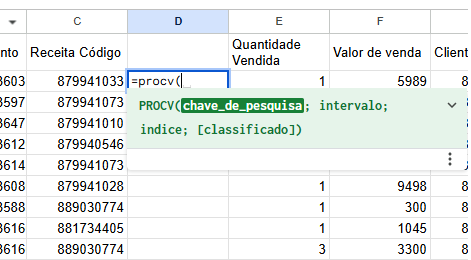

Em nossas aulas gravadas e agora também para o curso síncrono, incluímos a discussão do conceito de Join, que podemos utilizar com mais liberdade em programação Python

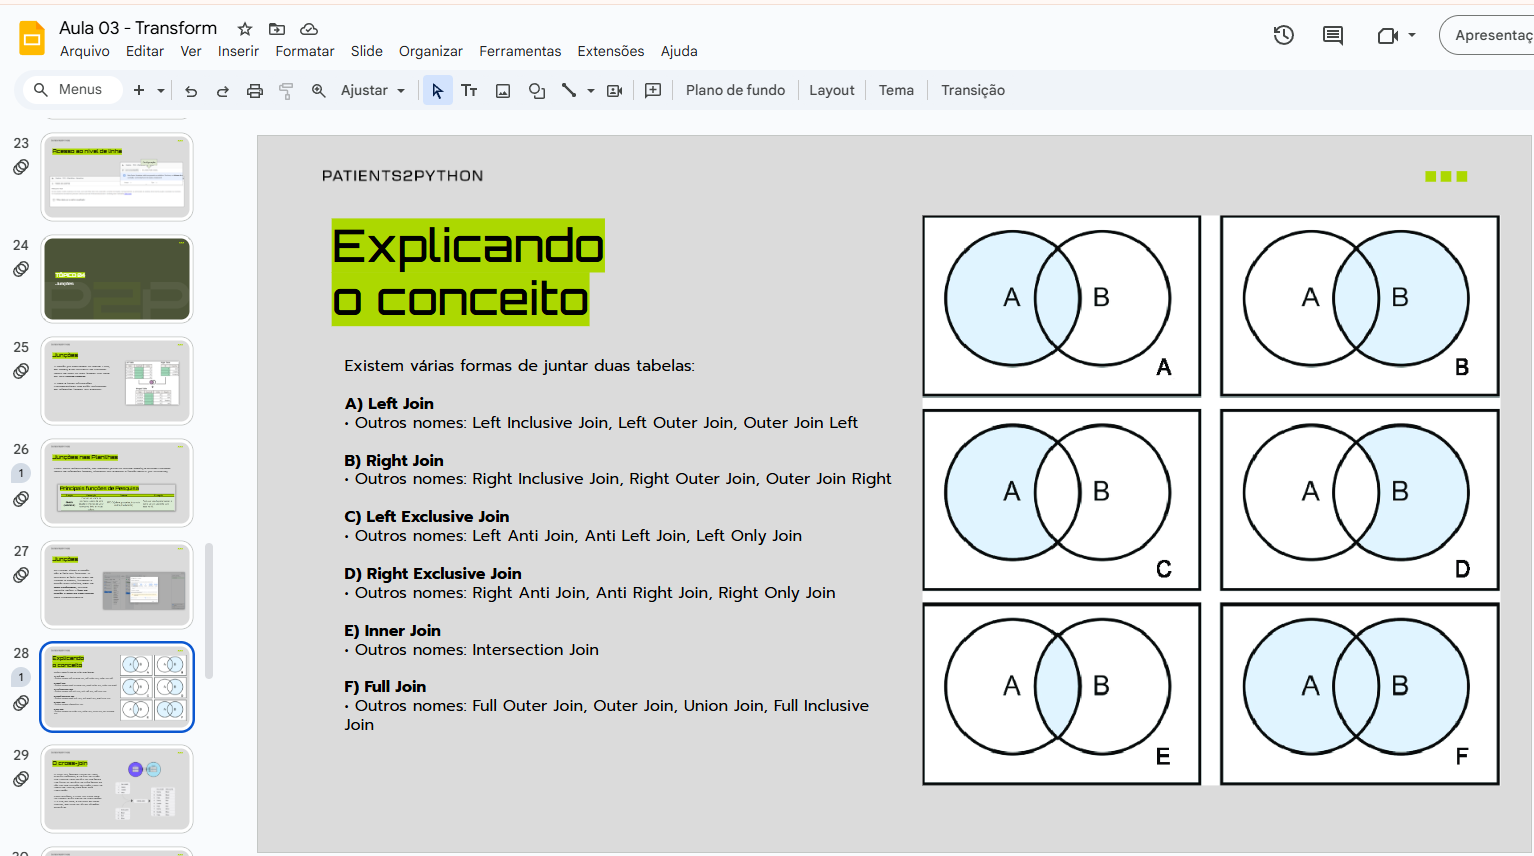

🔹 Basta passar os dataframes que quer juntar e as chaves que se quer utilizar para junção, assim como a forma de junção

In [720]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma', 'cliente_idade'],
      dtype='object')

In [721]:
df.dtypes

,0
atendimento_id,string[python]
lancamento_data,datetime64[ns]
cliente_id,string[python]
cliente_nome,object
cliente_sexo,object
cliente_data_nascimento,datetime64[ns]
profissional_nome,object
profissional_especialidade,object
receita_quantidade_vendida,int64
receita_valor_venda,float64


In [727]:
# Basta modificar o nome da aba entre aspas
sheet_name_2 = "Tipo de Receitas"

In [728]:
df_receitas_tipo = carregar_dataset(uploaded, sheet_name=sheet_name_2)

Arquivo identificado: Dados - TCC - Planilhas - Modificação 1 (2) (3).xlsx
Arquivo lido como Excel (xlsx)
Excel carregado com sucesso


In [729]:
df_receitas_tipo.columns

Index(['Código', 'Categoria', 'Nome', 'Imposto', 'Valor Sugerido',
       'Custo Unitário', 'Porcentagem Clínica'],
      dtype='object')

In [730]:
df_receitas_tipo.dtypes

,0
Código,int64
Categoria,object
Nome,object
Imposto,float64
Valor Sugerido,float64
Custo Unitário,float64
Porcentagem Clínica,float64


In [731]:
df_receitas_tipo['Código'] = df_receitas_tipo['Código'].astype(str)

In [739]:
def juntar_tabelas(df_esquerda, df_direita, left_on, right_on, tipo="left"):

    # informar que uma junção será realizada
    print("\nRealizando junção de tabelas")

    print(f"Tipo de junção: {tipo}")
    print(f"Chave da esquerda: {left_on}")
    print(f"Chave da direita: {right_on}")

    # dimensões antes do merge
    linhas_esquerda = len(df_esquerda)
    linhas_direita = len(df_direita)

    print(f"\nLinhas tabela esquerda: {linhas_esquerda}")
    print(f"Linhas tabela direita: {linhas_direita}")

    # realizar merge com indicador
    df_final = pd.merge(
        df_esquerda,
        df_direita,
        left_on=left_on,
        right_on=right_on,
        how=tipo,
        indicator=True
    )

    # contar resultados do join
    contagem = df_final["_merge"].value_counts()

    linhas_both = contagem.get("both", 0)
    linhas_left = contagem.get("left_only", 0)
    linhas_right = contagem.get("right_only", 0)

    print("\nResultado da junção")

    print(f"Linhas que juntaram (match nas duas tabelas): {linhas_both}")
    print(f"Linhas só na esquerda: {linhas_left}")
    print(f"Linhas só na direita: {linhas_right}")

    # dimensão final
    print(f"\nDimensão final da tabela: {df_final.shape}")

    # remover coluna auxiliar
    df_final = df_final.drop(columns=["_merge"])

    return df_final

In [735]:
# @title
from IPython.display import display, HTML

display(HTML("""
<style>
.cell .input {display:none;}
</style>

<div style="color:red;font-weight:bold;font-size:16px;">
⚠️ ALTERE AQUI A FORMA DE JUNÇÃO DAS TABELAS
</div>
"""))

In [740]:
df = juntar_tabelas(
    df,
    df_receitas_tipo,
    left_on="receita_codigo",
    right_on="Código",
    tipo="left"
)


Realizando junção de tabelas
Tipo de junção: left
Chave da esquerda: receita_codigo
Chave da direita: Código

Linhas tabela esquerda: 933
Linhas tabela direita: 374

Resultado da junção
Linhas que juntaram (match nas duas tabelas): 933
Linhas só na esquerda: 0
Linhas só na direita: 0

Dimensão final da tabela: (933, 36)


###### 🧩 Tabelas Dinâmicas

Em planilhas, utilizamos as velhas e boas Tabelas Dinâmicas, com um suporte do mouse

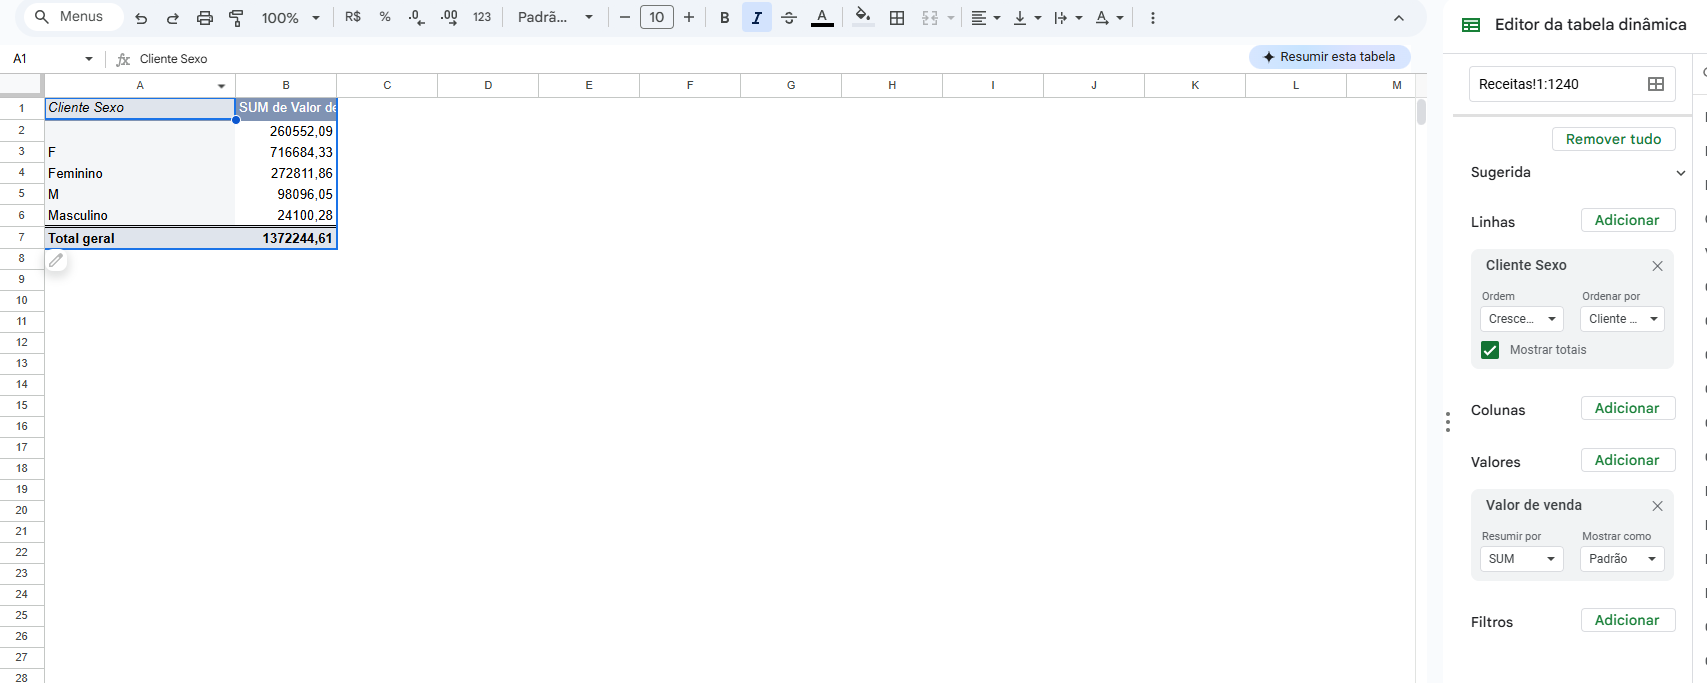

🔹 Em python também temos uma função para gerar tabelas dinâmicas! Os parâmetros são muito parecidos com as planilhas, veja só:

In [741]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma', 'cliente_idade', 'Código_x', 'Categoria_x', 'Nome_x',
       'Imposto_x', 'Valor Sugerido_x', 'Custo Unitário_x',
       'Porcentagem Clínica_x', 'Código_y', 'Categoria_y', 'Nome_y',
       'Imposto_y', 'Valor Sugerido_y', 'Custo Unitário_y',
       'Porcentagem Clínica_y', 'Código', 'Categoria', 'Nome', 'Imposto',
       'Valor Sugerido', 'Custo Unitário', 'Porcentagem Clínica'],
      dtype='object')

In [754]:
def criar_tabela_dinamica(
    df,
    indice,
    colunas=None,
    valores=None,
    agregacao="sum",
    fill_value=None,
    margins=False,
    margins_name="Total",
    percentual=None,
    observed=True
):

    # informar estrutura da tabela dinâmica
    print("\n📊 Criando tabela dinâmica")

    print(f"Índice (linhas): {indice}")
    print(f"Colunas: {colunas}")
    print(f"Valores agregados: {valores}")
    print(f"Função de agregação: {agregacao}")
    print(f"Percentual: {percentual}")

    # criar tabela dinâmica base
    tabela = pd.pivot_table(
        df,
        index=indice,
        columns=colunas,
        values=valores,
        aggfunc=agregacao,
        fill_value=fill_value,
        margins=margins,
        margins_name=margins_name,
        observed=observed
    )

    # calcular percentuais

    if percentual == "total":

        tabela = tabela / tabela.values.sum()

    elif percentual == "linha":

        tabela = tabela.div(tabela.sum(axis=1), axis=0)

    elif percentual == "coluna":

        tabela = tabela.div(tabela.sum(axis=0), axis=1)

    # transformar em percentual
    if percentual is not None:
        tabela = tabela * 100
        tabela = tabela.round(2)

    # mostrar resultado
    display(tabela)

    return tabela

In [756]:
tabela = criar_tabela_dinamica(
    df,
    indice="cliente_sexo",
    colunas="pagamento_forma",
    valores="receita_valor_venda",
    agregacao="sum",
    fill_value=0,
    margins=True,
)


📊 Criando tabela dinâmica
Índice (linhas): cliente_sexo
Colunas: pagamento_forma
Valores agregados: receita_valor_venda
Função de agregação: sum
Percentual: None


pagamento_forma,Boleto,Cartão de crédito à vista,Cartão de débito,Dinheiro,Pix,TED/DOC,Total
cliente_sexo,,,,,,,
Feminino,8100.0,95435.45,57501.0,21310.0,692010.65,22060.0,896417.10
Masculino,0.0,1675.00,9145.0,200.0,101165.93,0.0,112185.93
Total,8100.0,97110.45,66646.0,21510.0,793176.58,22060.0,1008603.03


In [759]:
tabela = criar_tabela_dinamica(
    df,
    indice="cliente_sexo",
    colunas="pagamento_forma",
    valores="receita_valor_venda",
    agregacao="sum",
    fill_value=0,
    percentual="linha",
    margins=True,
)


📊 Criando tabela dinâmica
Índice (linhas): cliente_sexo
Colunas: pagamento_forma
Valores agregados: receita_valor_venda
Função de agregação: sum
Percentual: linha


pagamento_forma,Boleto,Cartão de crédito à vista,Cartão de débito,Dinheiro,Pix,TED/DOC,Total
cliente_sexo,,,,,,,
Feminino,0.45,5.32,3.21,1.19,38.60,1.23,50.0
Masculino,0.00,0.75,4.08,0.09,45.09,0.00,50.0
Total,0.40,4.81,3.30,1.07,39.32,1.09,50.0


###### ∑ Agregações

🔹 Alternativamente, podemos utilizar a função groupby, muito conhecida do SQL. Passe as colunas pelas quais quer agregar (como dimensão). As colunas que quer agregar (como fato) e a forma de agregação

🔹 Mas essa função pode ser bem flexível

In [760]:
def agregar_dados(df, colunas_agregantes, dicionario_agregacoes, reset_index=True):

    # informar estrutura da agregação
    print("\n∑ Realizando agregação com groupby")

    print(f"Colunas de agrupamento: {colunas_agregantes}")
    print(f"Agregações definidas: {dicionario_agregacoes}")

    # executar agrupamento e agregações
    df_agregado = df.groupby(colunas_agregantes).aggregate(dicionario_agregacoes)

    # mostrar resultado inicial
    print("\nResultado bruto da agregação:")
    display(df_agregado)

    # resetar índice se desejado
    if reset_index:
        df_agregado = df_agregado.reset_index()

        print("\nÍndice resetado (transformando índices em colunas)")

    # verificar se existe MultiIndex nas colunas
    # e simplificar os nomes
    if isinstance(df_agregado.columns, pd.MultiIndex):

        print("\nSimplificando nomes das colunas (removendo MultiIndex)")

        df_agregado.columns = [
            "_".join(col).strip("_") for col in df_agregado.columns.values
        ]

    # mostrar resultado final
    print("\nResultado final da agregação:")
    display(df_agregado)

    return df_agregado

In [765]:
colunas_agregantes = ["cliente_sexo", "profissional_especialidade"]

dicionario_agregacoes = {
    "receita_valor_venda": ["sum", "mean", "max", "min"],
    "pagamento_data": ["min", "max"]
}

In [766]:
df.columns

Index(['atendimento_id', 'lancamento_data', 'cliente_id', 'cliente_nome',
       'cliente_sexo', 'cliente_data_nascimento', 'profissional_nome',
       'profissional_especialidade', 'receita_quantidade_vendida',
       'receita_valor_venda', 'receita_codigo', 'pagamento_data',
       'pagamento_forma', 'cliente_idade', 'Código_x', 'Categoria_x', 'Nome_x',
       'Imposto_x', 'Valor Sugerido_x', 'Custo Unitário_x',
       'Porcentagem Clínica_x', 'Código_y', 'Categoria_y', 'Nome_y',
       'Imposto_y', 'Valor Sugerido_y', 'Custo Unitário_y',
       'Porcentagem Clínica_y', 'Código', 'Categoria', 'Nome', 'Imposto',
       'Valor Sugerido', 'Custo Unitário', 'Porcentagem Clínica'],
      dtype='object')

In [767]:
df_agregado = agregar_dados(
    df,
    colunas_agregantes,
    dicionario_agregacoes
)


∑ Realizando agregação com groupby
Colunas de agrupamento: ['cliente_sexo', 'profissional_especialidade']
Agregações definidas: {'receita_valor_venda': ['sum', 'mean', 'max', 'min'], 'pagamento_data': ['min', 'max']}

Resultado bruto da agregação:


receita_valor_venda               \
                                                        sum         mean   
cliente_sexo profissional_especialidade                                    
Feminino     Cirurgia Plástica                    554213.32  1325.869187   
             Dermatologia                         147921.98  1079.722482   
             Educador Físico                         200.00   200.000000   
             Ginecologia                           87522.30   444.275635   
             Nutricionista                          1500.00   214.285714   
             Nutrologia                           101959.50  1359.460000   
             Psicólogo                              3100.00   516.666667   
Masculino    Cirurgia Plástica                     57290.43  1909.681000   
             Dermatologia                          18855.00   589.218750   
             Ginecologia                             650.00   325.000000   
             Nutricionista                           400.00   200.000000   
             Nutrologia                            34590.50  1441.270833   
             Psicólogo                               400.00   200.000000   

                                                          pagamento_data  \
                                              max     min            min   
cliente_sexo profissional_especialidade                                    
Feminino     Cirurgia Plástica           20217.40  133.35     2021-10-21   
             Dermatologia                 4500.00  200.00     2022-03-03   
             Educador Físico               200.00  200.00     2023-06-19   
             Ginecologia                  3000.00  126.84     2022-04-13   
             Nutricionista                 250.00  200.00     2023-06-04   
             Nutrologia                   4200.00  582.00     2022-03-07   
             Psicólogo                     900.00  200.00     2023-05-08   
Masculino    Cirurgia Plástica           14066.43  123.00     2021-11-30   
             Dermatologia                 1300.00  240.00     2022-03-23   
             Ginecologia                   350.00  300.00     2022-07-03   
             Nutricionista                 200.00  200.00     2023-12-08   
             Nutrologia                   3000.00  600.00     2022-03-04   
             Psicólogo                     200.00  200.00     2023-06-21   

                                                    
                                               max  
cliente_sexo profissional_especialidade             
Feminino     Cirurgia Plástica          2024-07-05  
             Dermatologia               2024-06-20  
             Educador Físico            2023-06-19  
             Ginecologia                2024-06-14  
             Nutricionista              2024-06-16  
             Nutrologia                 2024-06-16  
             Psicólogo                  2023-10-10  
Masculino    Cirurgia Plástica          2024-04-29  
             Dermatologia               2024-04-02  
             Ginecologia                2023-03-04  
             Nutricionista              2024-01-17  
             Nutrologia                 2024-03-17  
             Psicólogo                  2023-06-30


Índice resetado (transformando índices em colunas)

Simplificando nomes das colunas (removendo MultiIndex)

Resultado final da agregação:


,cliente_sexo,profissional_especialidade,receita_valor_venda_sum,receita_valor_venda_mean,receita_valor_venda_max,receita_valor_venda_min,pagamento_data_min,pagamento_data_max
0,Feminino,Cirurgia Plástica,554213.32,1325.869187,20217.40,133.35,2021-10-21,2024-07-05
1,Feminino,Dermatologia,147921.98,1079.722482,4500.00,200.00,2022-03-03,2024-06-20
2,Feminino,Educador Físico,200.00,200.000000,200.00,200.00,2023-06-19,2023-06-19
3,Feminino,Ginecologia,87522.30,444.275635,3000.00,126.84,2022-04-13,2024-06-14
4,Feminino,Nutricionista,1500.00,214.285714,250.00,200.00,2023-06-04,2024-06-16
5,Feminino,Nutrologia,101959.50,1359.460000,4200.00,582.00,2022-03-07,2024-06-16
6,Feminino,Psicólogo,3100.00,516.666667,900.00,200.00,2023-05-08,2023-10-10
7,Masculino,Cirurgia Plástica,57290.43,1909.681000,14066.43,123.00,2021-11-30,2024-04-29
8,Masculino,Dermatologia,18855.00,589.218750,1300.00,240.00,2022-03-23,2024-04-02
9,Masculino,Ginecologia,650.00,325.000000,350.00,300.00,2022-07-03,2023-03-04


# **📦 Load**

## ⬇️  Download

## 📊 Plotagem

#####  Matplotlib

#####  Seaborn

#####  Plotly